In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



# Prepare Data for Modeling

In [2]:
# Load engineered dataset
df = pd.read_csv("engineered_customer_data.csv")

# Separate features (X) and target (y)
X = df.drop('ChurnStatus', axis=1)  # All features except target
y = df['ChurnStatus']               # Target variable

# Split into train/test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale numerical features (important for Logistic Regression)
scaler = StandardScaler()
num_cols = ['Age', 'AvgSpendingPerMonth', 'DaysSinceLastLogin', 
            'DaysSinceLastTransaction', 'ComplaintRatio', 'ResolutionSuccessRate']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Model Selection 

In [4]:
!pip install xgboost

   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.5/56.8 MB 2.2 MB/s eta 0:00:26
    --------------------------------------- 1.3/56.8 MB 2.8 MB/s eta 0:00:20
   - -------------------------------------- 1.6/56.8 MB 2.5 MB/s eta 0:00:23
   - -------------------------------------- 2.1/56.8 MB 2.5 MB/s eta 0:00:22
   -- ------------------------------------- 2.9/56.8 MB 2.7 MB/s eta 0:00:21
   -- ------------------------------------- 3.7/56.8 MB 2.8 MB/s eta 0:00:20
   -- ------------------------------------- 4.2/56.8 MB 2.8 MB/s eta 0:00:20
   --- ------------------------------------ 4.5/56.8 MB 2.6 MB/s eta 0:00:20
   --- ------------------------------------ 5.2/56.8 MB 2.7 MB/s eta 0:00:19
   ---- ----------------------------------- 5.8/56.8 MB 2.7 MB/s eta 0:00:20
   ---- ----------------------------------- 6.3/56.8 MB 2.7 MB/s eta 0:00:19
   ---- -----

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = {}

for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # Probabilities for AUC
    
    # Evaluate
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob)
    }

# Convert results to DataFrame
results_df = pd.DataFrame(results).T
print(results_df)

                     Accuracy  Precision    Recall        F1   AUC-ROC
Logistic Regression  0.792507   0.000000  0.000000  0.000000  0.614032
Random Forest        0.993276   0.990566  0.976744  0.983607  0.998176
XGBoost              0.994236   0.990610  0.981395  0.985981  0.991520


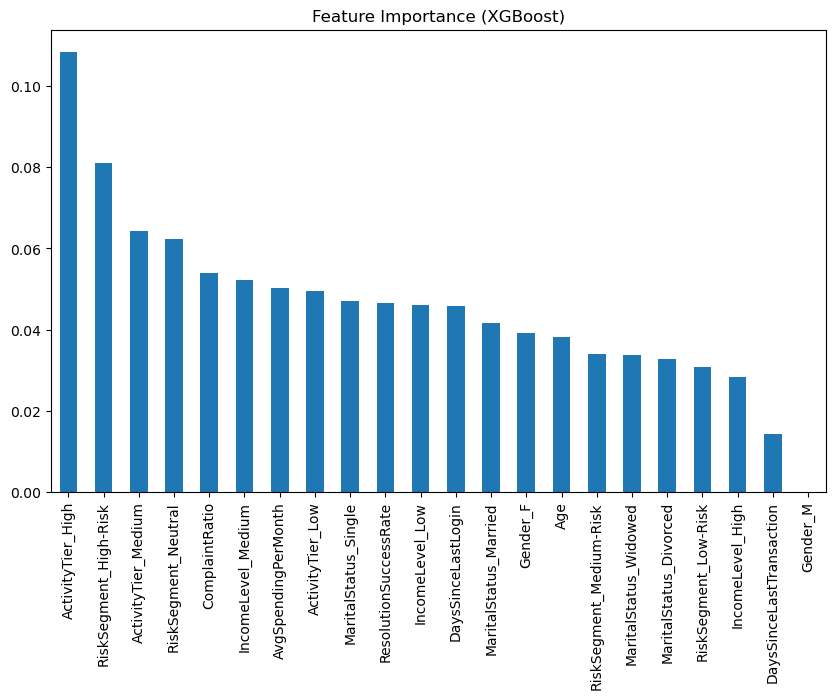

In [7]:
import matplotlib.pyplot as plt

# Fit XGBoost (best performer)
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)

# Plot feature importance
plt.figure(figsize=(10, 6))
pd.Series(xgb.feature_importances_, index=X_train.columns) \
  .sort_values(ascending=False) \
  .plot(kind='bar', title="Feature Importance (XGBoost)")
plt.show()

In [10]:
#from sklearn.model_selection import cross_val_score
#print(cross_val_score(xgb, X, y, cv=5, scoring='f1'))